In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Data Set

df = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/master/Data%20Sets/Iris%20(5).csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
153,154,7.5,3.0,6.6,2.1,NaN
154,155,5.7,3.0,4.2,1.2,NaN
155,156,5.5,3.4,1.5,0.4,NaN
156,157,4.7,3.0,1.4,0.3,NaN


#DATA CLEANING

In [ ]:
# Drop unwanted columns that will not contribute to the prediction of 'Species'

df.drop(columns=['Id'], inplace=True)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Check for Missing Data

df.isnull().sum()

# species = 8 --> these are from row 150-157

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,8


In [ ]:
# Check number of classes

df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica', nan],
      dtype=object)

In [ ]:
df_grouped = df.groupby('Species').mean()
df_grouped

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [ ]:
# Replace NaN values in 'Species'

df.at[150, 'Species'] = 'Iris-versicolor'
df.at[151, 'Species'] = 'Iris-virginica'
df.at[152, 'Species'] = 'Iris-setosa'
df.at[153, 'Species'] = 'Iris-virginica'
df.at[154, 'Species'] = 'Iris-versicolor'
df.at[155, 'Species'] = 'Iris-setosa'
df.at[156, 'Species'] = 'Iris-setosa'
df.at[157, 'Species'] = 'Iris-virginica'

df.tail(8)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
150,5.6,2.9,4.2,1.3,Iris-versicolor
151,7.1,3.2,6.0,1.8,Iris-virginica
152,4.6,2.3,1.3,0.3,Iris-setosa
153,7.5,3.0,6.6,2.1,Iris-virginica
154,5.7,3.0,4.2,1.2,Iris-versicolor
155,5.5,3.4,1.5,0.4,Iris-setosa
156,4.7,3.0,1.4,0.3,Iris-setosa
157,7.6,3.0,6.1,2.3,Iris-virginica


# SVM

In [ ]:
# Add Validation Dataset

data = [[3.15, 3.2, 1.21, 0.2, -1],
       [1.35, 4.1, 1.7, 0.2, -1]]

validation_data = np.array(data)
validation_data = pd.DataFrame(data, index = [158, 159], columns = df.columns)
validation_data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
158,3.15,3.2,1.21,0.2,-1
159,1.35,4.1,1.70,0.2,-1


In [ ]:
# Insert New Data to Original DataFrame

df = pd.concat([df, validation_data], axis = 0)
df.replace(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], [0,1,2], inplace = True) # Iris-setosa', 'Iris-versicolor', 'Iris-virginica'
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
155,5.50,3.4,1.50,0.4,0
156,4.70,3.0,1.40,0.3,0
157,7.60,3.0,6.10,2.3,2
158,3.15,3.2,1.21,0.2,-1
159,1.35,4.1,1.70,0.2,-1


In [ ]:
# Data Scaling

X = df.drop('Species', axis = 1)

scaler = StandardScaler()
scaler.fit(X) # This line fit the scaler to the data

StandardScaler()

In [ ]:
# Scale the data

scaled_features_data = scaler.transform(X)
scaled_features_data

array([[-0.75735717,  1.02411419, -1.30903466, -1.2916446 ],
       [-0.97126211, -0.13307699, -1.30903466, -1.2916446 ],
       [-1.18516705,  0.32979949, -1.36503464, -1.2916446 ],
       [-1.29211952,  0.09836125, -1.25303467, -1.2916446 ],
       [-0.86430964,  1.25555243, -1.30903466, -1.2916446 ],
       [-0.43649976,  1.94986714, -1.1410347 , -1.02988002],
       [-1.29211952,  0.79267596, -1.30903466, -1.16076231],
       [-0.86430964,  0.79267596, -1.25303467, -1.2916446 ],
       [-1.50602445, -0.36451522, -1.30903466, -1.2916446 ],
       [-0.97126211,  0.09836125, -1.25303467, -1.42252689],
       [-0.43649976,  1.48699067, -1.25303467, -1.2916446 ],
       [-1.07821458,  0.79267596, -1.19703469, -1.2916446 ],
       [-1.07821458, -0.13307699, -1.30903466, -1.42252689],
       [-1.61297692, -0.13307699, -1.47703461, -1.42252689],
       [-0.00868989,  2.18130537, -1.42103463, -1.2916446 ],
       [-0.11564236,  3.10705832, -1.25303467, -1.02988002],
       [-0.43649976,  1.

In [ ]:
# Convert scaled_features_data (numpy array to DataFrame)

scaled_features_data = pd.DataFrame(scaled_features_data, columns = df.columns[:-1]) # all columns except 'Species'
scaled_features_data.tail()

#df.columns

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
155,-0.329547,0.792676,-1.253035,-1.029880
156,-1.185167,-0.133077,-1.309035,-1.160762
157,1.916455,-0.133077,1.322965,1.456883
158,-2.842930,0.329799,-1.415435,-1.291645
159,-4.768075,2.412744,-1.141035,-1.291645


In [ ]:
# Set X (features) and y (Class Target)

X = scaled_features_data.iloc[:158,:] # Check the original data
y = df.iloc[:158, -1]

In [ ]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.757357,1.024114,-1.309035,-1.291645
1,-0.971262,-0.133077,-1.309035,-1.291645
2,-1.185167,0.329799,-1.365035,-1.291645
3,-1.292120,0.098361,-1.253035,-1.291645
4,-0.864310,1.255552,-1.309035,-1.291645
...,...,...,...,...
153,1.809502,-0.133077,1.602965,1.195119
154,-0.115642,-0.133077,0.258965,0.017178
155,-0.329547,0.792676,-1.253035,-1.029880
156,-1.185167,-0.133077,-1.309035,-1.160762


In [ ]:
y

,Species
0,0
1,0
2,0
3,0
4,0
...,...
153,2
154,1
155,0
156,0


In [ ]:
# Train - Test Split Proper

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 101)

# Show X_train

X_train

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
65,0.953882,0.098361,0.370965,0.278943
100,0.526072,0.561238,1.266965,1.718648
67,-0.008690,-0.827392,0.202965,-0.244586
21,-0.757357,1.486991,-1.253035,-1.029880
22,-1.292120,1.255552,-1.533035,-1.291645
...,...,...,...,...
63,0.312168,-0.364515,0.538965,0.278943
70,0.098263,0.329799,0.594965,0.802472
81,-0.329547,-1.521706,-0.021035,-0.244586
11,-1.078215,0.792676,-1.197035,-1.291645


In [ ]:
# Show y_train

y_train

,Species
65,1
100,2
67,1
21,0
22,0
...,...
63,1
70,1
81,1
11,0


In [ ]:
# Support Vector Machine Classifier

model = SVC(kernel = 'linear', C = 1)
model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [ ]:
# Prediction on X_test

predictions = model.predict(X_test)
predictions

array([2, 0, 1, 2, 0, 2, 1, 2, 0, 1, 2, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 2, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 0, 2, 2, 2, 1, 2,
       2, 1, 1, 0])

<Axes: >

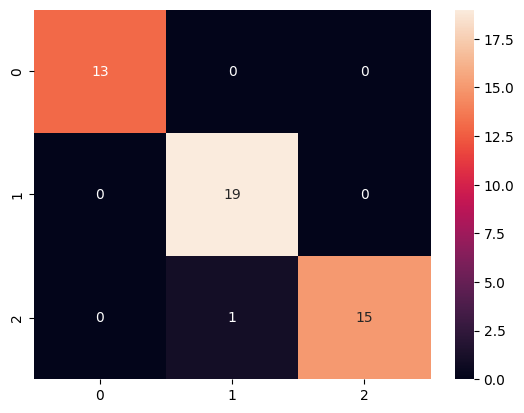

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot = True, fmt = 'd')

In [ ]:
# Accuracy Score

print(accuracy_score(y_test, predictions))

0.9791666666666666


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        16

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



#QUESTIONS

In [ ]:
# 6. What is the the best model based on grid search with the following values: {'C': [0.01, 0.05, 0.1, 0.5, 1, 1.5, 3, 5, 10, 25, 50, 100], 'kernel': ['linear', 'rbf', 'poly']}

from sklearn.model_selection import GridSearchCV

svm = SVC()
param_grid = {'C': [0.01, 0.05, 0.1, 0.5, 1, 1.5, 3, 5, 10, 25, 50, 100], 'kernel': ['linear', 'rbf', 'poly']}
grid = GridSearchCV(svm, param_grid)
grid.fit(X, y)


GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1, 1.5, 3, 5, 10, 25, 50,
                               100],
                         'kernel': ['linear', 'rbf', 'poly']})

In [ ]:
# 7. Using the best parameter, what is the accuracy of the SVM model?

# Support Vector Machine Classifier

model = SVC(kernel = 'poly', C = 50)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(accuracy_score(y_test, predictions) * 100)

97.91666666666666


<Axes: >

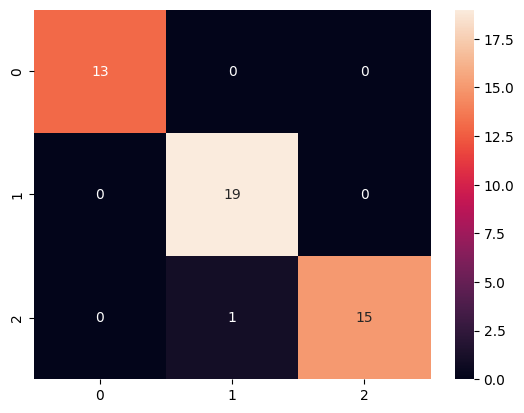

In [ ]:
# 8. What is the True Positive value based on the confusion matrix of the best model?

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot = True, fmt = 'd')

In [ ]:
# 9. What is the 'Species' for validation data number 1?
# 10. What is the 'Species' for validation data number 2?

validation_feature = scaled_features_data.iloc[158:,:]
y_predict = model.predict(validation_feature)

pd.concat([validation_feature, pd.DataFrame(y_predict, index = list(range(158,158+y_predict.shape[0])), columns = ['Species'])], axis = 1)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
158,-2.842930,0.329799,-1.415435,-1.291645,0
159,-4.768075,2.412744,-1.141035,-1.291645,0
